In [2]:
'''
Pull species data from GBIF
predicates found at https://gbif.github.io/gbif-api/apidocs/org/gbif/api/model/occurrence/search/OccurrenceSearchParameter.html
issues: https://techdocs.gbif.org/en/data-use/occurrence-issues-and-flags
'''
#!pip install pygbif
import geopandas as gpd
from pygbif import occurrences
from shapely.geometry import Point
import pandas as pd
import requests
from shapely.geometry import box
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

output_dir = "/mnt/f/gbif"
aoi = gpd.read_parquet("mav_counties_4326.parquet").set_crs("EPSG:4326", allow_override=True)

In [4]:

# ----------------------------
# Step 2: Define species & query options
# ----------------------------

species_list = [
    "Odocoileus virginianus",     # white tailed deer
    "Ursus americanus",           # Black bear
    "Anaxyrus americanus",        # American Toad
    "Anaxyrus fowleri",           # Fowler's Toad
    "Gastrophryne carolinensis",  # Eastern Narrow-mouthed Toad
    "Hyla avivoca",               # Bird-voiced Treefrog
    "Hyla chrysoscelis",          # Cope's Gray Treefrog
    "Hyla cinerea",               # Green Treefrog
    "Hyla squirella",             # Squirrel Treefrog    
    "Hyla versicolor",            # Gray Treefrog
    "Lithobates catesbeianus",    # American Bullfrog
    "Lithobates clamitans",       # Bronze Frog
    "Lithobates palustris",       # Pickerel Frog
    "Lithobates sphenocephalus",  # Southern Leopard Frog
    "Pseudacris crucifer",        # Spring Peeper
    "Pseudacris fouquettei",      # Cajun Chorus Frog
    "Kinosternon subrubrum",      # Eastern Mud Turtle
    "Apalone spinifera",          # Spiny Softshell Turtle   
    "Macrochelys temmincki"       # Alligator Snapping Turtle      
]

year_min = 2017
year_max = 2024
uncertainty_limit = 100  # meters

yearlist = list(range(year_min, year_max + 1))

def query_species(scientific_name, year, aoi=None, max_records=50000):
    base_url = "https://api.gbif.org/v1/occurrence/search"
    limit = 300  # max allowed per GBIF API
    offset = 0
    all_records = []

    # If AOI is provided, get its bounding box
    if aoi is not None:
        bounds = aoi.total_bounds  # (minx, miny, maxx, maxy)
        bbox = {
            'decimalLatitude': f"{bounds[1]},{bounds[3]}",
            'decimalLongitude': f"{bounds[0]},{bounds[2]}"
        }
    else:
        bbox = {}
    while True:
        params = {
            'scientificName': scientific_name,
            'hasCoordinate': 'true',
            'limit': limit,
            'offset': offset,
            'year': year,
            **bbox
        }
        response = requests.get(base_url, params=params)
        response.raise_for_status()
        data = response.json()

        records = data.get('results', [])
        if not records:
            break

        df = pd.json_normalize(records)
        all_records.append(df)

        offset += limit
        if offset >= data.get('count', 0) or offset >= max_records:
            break

    if all_records:
        return pd.concat(all_records, ignore_index=True)
    else:
        return pd.DataFrame()

In [3]:
# Create a folder to store the outputs
os.makedirs(output_dir, exist_ok=True)
# ----------------------------
# Step 4: Process each species
# ----------------------------
#all_species = []

for name in species_list:
    print('name',name)
    for year in yearlist:
        print('year', year)
        try:
            df = query_species(name, year, aoi)
            print(df.columns)
        except Exception as e:
            print('error', e)
            continue

        if df.empty:
            continue
        # Keep only valid rows
        df = df[df['decimalLatitude'].notna() & df['decimalLongitude'].notna()]
        # Create GeoDataFrame
        gdf = gpd.GeoDataFrame(
            df,#[['species','occurrenceStatus', 'basisOfRecord', 'coordinateUncertaintyInMeters', 'decimalLatitude', 'decimalLongitude']],
            geometry=[Point(xy) for xy in zip(df['decimalLongitude'], df['decimalLatitude'])],
            crs="EPSG:4326"
        )
        gdf = gdf.rename(columns={'decimalLatitude':'Latitude', 'decimalLongitude':'Longitude'})
        #gdf = gdf[['occurrencestatus', 'basisofrecord', 'coordinateUncertaintyInMeters', 'decimalLongitude', 'decimalLatitude', 'geometry']]
        # Clip to AOI
        gdf_clipped = gpd.overlay(gdf, aoi, how='intersection')

        # Skip if no clipped data
        if gdf_clipped.empty:
            print('No records for {0}'.format(name))
            continue
        
        gdf_clipped = gdf_clipped.rename(columns=lambda column: column.lower().strip().replace(' ', '_'))
        # Add to list
        gdf_clipped['species'] = gdf_clipped['species'].str.lower().str.strip().str.replace(' ', '_')
        #all_species.append(gdf_clipped)

        # ✅ Save to CSV
        safe_name = name.lower().strip().replace(" ", "_").replace("/", "_")
        output_path = os.path.join(output_dir, f"{safe_name}_{year}.csv")
        gdf_clipped.drop(columns='geometry').to_csv(output_path, index=False)
        print(f"💾 Saved {len(gdf_clipped)} records for '{name}' to {output_path}")


name Odocoileus virginianus
year 2017
Index(['key', 'datasetKey', 'publishingOrgKey', 'installationKey',
       'hostingOrganizationKey', 'publishingCountry', 'protocol',
       'lastCrawled', 'lastParsed', 'crawlId',
       ...
       'gadm.level1.name', 'gadm.level2.gid', 'gadm.level2.name',
       'occurrenceRemarks', 'dynamicProperties', 'identificationRemarks',
       'lifeStage', 'vitality', 'informationWithheld', 'sex'],
      dtype='object', length=139)
💾 Saved 36 records for 'Odocoileus virginianus' to /mnt/f/gbif/odocoileus_virginianus_2017.csv
year 2018
Index(['key', 'datasetKey', 'publishingOrgKey', 'installationKey',
       'hostingOrganizationKey', 'publishingCountry', 'protocol',
       'lastCrawled', 'lastParsed', 'crawlId',
       ...
       'http://unknown.org/recordID', 'associatedTaxa', 'locality', 'county',
       'fieldNumber', 'taxonRemarks', 'rights', 'collectionID',
       'higherClassification',
       'extensions.http://rs.tdwg.org/dwc/terms/Identification'],

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [15]:
list(data.columns)

['key',
 'datasetkey',
 'publishingorgkey',
 'installationkey',
 'hostingorganizationkey',
 'publishingcountry',
 'protocol',
 'lastcrawled',
 'lastparsed',
 'crawlid',
 'projectid',
 'basisofrecord',
 'occurrencestatus',
 'taxonkey',
 'kingdomkey',
 'phylumkey',
 'classkey',
 'orderkey',
 'familykey',
 'genuskey',
 'specieskey',
 'acceptedtaxonkey',
 'scientificname',
 'scientificnameauthorship',
 'acceptedscientificname',
 'kingdom',
 'phylum',
 'order',
 'family',
 'genus',
 'species',
 'genericname',
 'specificepithet',
 'taxonrank',
 'taxonomicstatus',
 'iucnredlistcategory',
 'dateidentified',
 'latitude',
 'longitude',
 'coordinateuncertaintyinmeters',
 'continent',
 'stateprovince',
 'year',
 'month',
 'day',
 'eventdate',
 'startdayofyear',
 'enddayofyear',
 'issues',
 'modified',
 'lastinterpreted',
 'references',
 'license',
 'issequenced',
 'identifiers',
 'media',
 'facts',
 'relations',
 'isincluster',
 'datasetname',
 'recordedby',
 'identifiedby',
 'dnasequenceid',
 'ge

TypeError: makedirs() got an unexpected keyword argument 'exists_ok'. Did you mean 'exist_ok'?

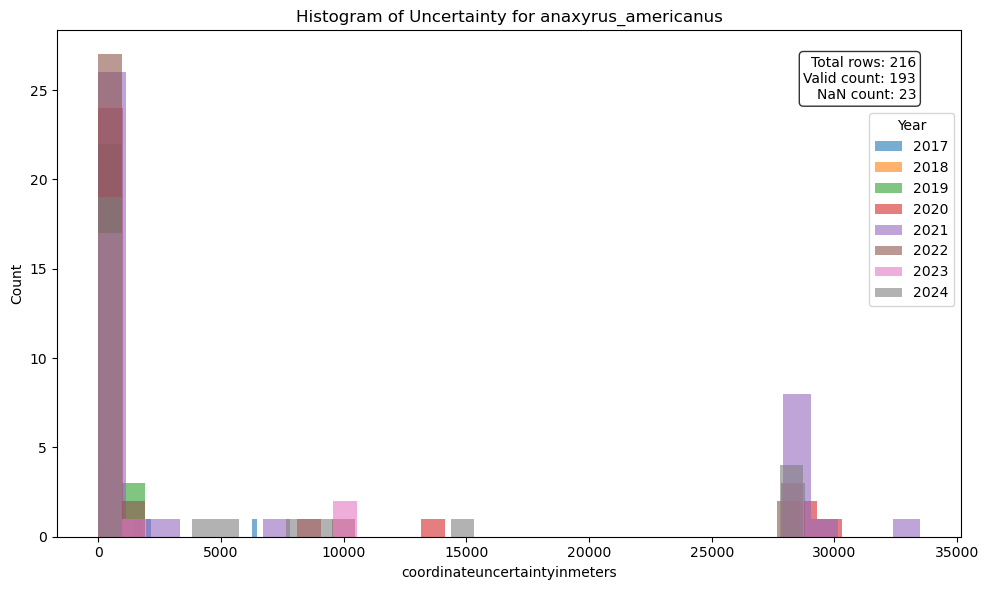

In [5]:
# --------------------------
# 1. Path to folder containing species csvs.  If running all together should be the same as the output_dir defined above
# --------------------------
folder_path = output_dir

# --------------------------
# 2. Read all CSVs into a single DataFrame
# --------------------------
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

dfs = []
for f in all_files:
    df = pd.read_csv(f)
    
    # Extract species and year from filename
    basename = os.path.basename(f).replace(".csv", "")
    try:
        species, year = basename.rsplit("_", 1)
        df["species"] = species
        df["year"] = int(year)
    except ValueError:
        pass
    
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

# --------------------------
# 3. Plot histogram by species, colored by year
# --------------------------
species_list = data['species'].unique()
colors = plt.cm.tab10.colors  # up to 10 distinct colors

for species in species_list:
    subset = data[data['species'] == species]
    
    plt.figure(figsize=(10,6))
    
    # Plot histogram for each year, ignoring NaNs
    years = sorted(subset['year'].dropna().unique())
    for i, year in enumerate(years):
        year_data = subset[subset['year'] == year]['coordinateuncertaintyinmeters'].dropna()
        plt.hist(year_data, bins=30, alpha=0.6, color=colors[i % 10], label=str(year))
    
    # Compute NaN count
    n_nan = subset['coordinateuncertaintyinmeters'].isna().sum()
    total = len(subset)
    total_non_nan = total - n_nan
    
    # Add text with counts
    plt.text(
        0.95, 0.95,
        f"Total rows: {total}\nValid count: {total_non_nan}\nNaN count: {n_nan}",
        transform=plt.gca().transAxes,
        ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
    )
    
    plt.xlabel("coordinateuncertaintyinmeters")
    plt.ylabel("Count")
    plt.title(f"Histogram of Uncertainty for {species}")
    plt.legend(
    title="Year",
        loc="upper right",          # anchor point of the legend
        bbox_to_anchor=(1, 0.85)    # move slightly down (0.85 instead of 1)
    )
    plt.tight_layout()
    #plt.show()
    # --------------------------
    # Save as JPG
    # --------------------------
    out_path = os.path.join(output_dir,'uncertainty',f"{species}_uncertainty.jpg")
    os.makedirs(os.path.join(output_dir,'uncertainty'), exists_ok=True)
    plt.savefig(out_path, dpi=300)
    
    plt.close()  # close figure to avoid overlap between species
print('complete')

In [7]:
def flag_coarse_coordinates(
    data,
    lat_col="latitude",
    lon_col="longitude",
    county_shp_path=None,
    state_shp_path=None,
    tolerance_m=50
):
    # 1. Create GeoDataFrame
    gdf = gpd.GeoDataFrame(
        data,
        geometry=gpd.points_from_xy(data[lon_col], data[lat_col]),
        crs="EPSG:4326"
    )

    # Project to equal-area metric CRS
    gdf_proj = gdf.to_crs(epsg=5070)

    # Initialize flags
    gdf_proj['at_county_centroid'] = False
    gdf_proj['at_state_centroid'] = False

    # --------------------------
    # County centroids
    # --------------------------
    if county_shp_path:
        counties = (
            gpd.read_parquet(county_shp_path)
            .to_crs(epsg=5070)
            .assign(centroid=lambda x: x.geometry.centroid)
            .set_geometry('centroid')
        )

        # Spatial join: nearest centroid
        join = gpd.sjoin_nearest(
            gdf_proj,
            counties[['centroid']],
            how='left',
            distance_col='county_dist'
        )

        gdf_proj['at_county_centroid'] = join['county_dist'] <= tolerance_m

    # --------------------------
    # State centroids
    # --------------------------
    if state_shp_path:
        states = (
            gpd.read_file(state_shp_path)
            .to_crs(epsg=5070)
            .assign(centroid=lambda x: x.geometry.centroid)
            .set_geometry('centroid')
        )

        join = gpd.sjoin_nearest(
            gdf_proj,
            states[['centroid']],
            how='left',
            distance_col='state_dist'
        )

        gdf_proj['at_state_centroid'] = join['state_dist'] <= tolerance_m

    # --------------------------
    # Final coarse flag
    # --------------------------
    gdf_proj['coarse_flag'] = (
        gdf_proj['at_county_centroid'] |
        gdf_proj['at_state_centroid']
    )

    return gdf_proj.to_crs(epsg=4326)

In [10]:
county_shp = r"/mnt/e/gis/BaseData/us_counties1.parquet"
state_shp = r"/mnt/e/gis/BaseData/State.shp"

gdf_checked = flag_coarse_coordinates(
    data[data['species']=='Protonotaria_citrea'],
    lat_col="latitude",
    lon_col="longitude",
    county_shp_path=county_shp,
    state_shp_path=state_shp,
    tolerance_m=500
)

# How many flagged?
print(f'Total points: {len(data)}')
print(f"Points near county centroids: {gdf_checked['at_county_centroid'].sum()}")
print(f"Points near state centroids: {gdf_checked['at_state_centroid'].sum()}")
print(f"Total coarse points: {gdf_checked['coarse_flag'].sum()}")

# Filter out coarse points if desired
clean_gdf = gdf_checked[~gdf_checked['coarse_flag']]


Total points: 9227
Points near county centroids: 0
Points near state centroids: 0
Total coarse points: 0


In [11]:
import requests
import zipfile
import io

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

# Download
r = requests.get(url, verify=False)
r.raise_for_status()

# Extract to a temporary folder
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("natural_earth")  # extracts into folder "natural_earth"


# Find the .shp inside the folder
shp_path = os.path.join("natural_earth", "ne_110m_admin_0_countries.shp")
world = gpd.read_file(shp_path)

print(world.head())


/home/mike/miniforge3/envs/rapids-25.10/lib/python3.13/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'naturalearth.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


        featurecla  scalerank  LABELRANK                   SOVEREIGNT SOV_A3  \
0  Admin-0 country          1          6                         Fiji    FJI   
1  Admin-0 country          1          3  United Republic of Tanzania    TZA   
2  Admin-0 country          1          7               Western Sahara    SAH   
3  Admin-0 country          1          2                       Canada    CAN   
4  Admin-0 country          1          2     United States of America    US1   

   ADM0_DIF  LEVEL               TYPE TLC                        ADMIN  ...  \
0         0      2  Sovereign country   1                         Fiji  ...   
1         0      2  Sovereign country   1  United Republic of Tanzania  ...   
2         0      2      Indeterminate   1               Western Sahara  ...   
3         0      2  Sovereign country   1                       Canada  ...   
4         1      2            Country   1     United States of America  ...   

      FCLASS_TR     FCLASS_ID     FCLASS_PL 

In [12]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

from geopandas.datasets import get_path

def clean_coordinates(
    df,
    world,
    lon_col="longitude",
    lat_col="latitude",
    uncertainty_col="coordinateUncertaintyInMeters",
    uncertainty_threshold=5000,  # meters
    centroid_tol_km=5,
    capital_tol_km=5,
    drop_duplicates=True,
):
    """
    Mimics CoordinateCleaner::clean_coordinates() in R.
    Flags spatially problematic GBIF-style occurrence records.
    """

    # Convert to GeoDataFrame
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df[lon_col], df[lat_col]),
        crs="EPSG:4326",
    )
    gdf = gdf.to_crs(5070)

    # Initialize flag columns
    flags = {
        "flag_centroid": False,
        "flag_capital": False,
        "flag_ocean": False,
        "flag_zero": False,
        "flag_duplicate": False,
        "flag_uncertainty": False,
    }
    for k in flags.keys():
        gdf[k] = False

    # --- Load geographic reference data ---
    world = world.to_crs(5070)
    world["centroid"] = world.geometry.centroid

    # Capital coordinates (from world dataset; some are missing)
    # Use SOVEREIGNT as country name instead of 'name'
    capitals = world[["SOVEREIGNT", "geometry"]].copy()
    capitals["geometry"] = world.geometry.centroid


    # --- Zero coordinate filter ---
    gdf.loc[
        (gdf[lon_col].abs() < 1e-6) & (gdf[lat_col].abs() < 1e-6),
        "flag_zero"
    ] = True


    # --- Ocean filter (robust, handles duplicate matches) ---
    on_land = gpd.sjoin(
        gdf,
        world[["geometry"]],
        how="left",
        predicate="within",
    )
    
    # A point is on land if it matched ANY polygon
    on_land_flag = (
        on_land
        .groupby(level=0)["index_right"]
        .apply(lambda x: x.notna().any())
    )
    
    # Align safely back to gdf (missing -> False)
    gdf["flag_ocean"] = ~on_land_flag.reindex(gdf.index, fill_value=False)


    # --- Country centroid filter ---
    centroid_tol_m = centroid_tol_km * 1000
    capital_tol_m = capital_tol_km * 1000

    for _, row in world.iterrows():
        near = gdf.geometry.distance(row["centroid"]) < centroid_tol_m
        gdf.loc[near, "flag_centroid"] = True

    # --- Capital filter ---
    for _, row in capitals.iterrows():
        near = gdf.geometry.distance(row.geometry) < (capital_tol_km / 111)
        gdf.loc[near, "flag_capital"] = True

    # --- Duplicate coordinates filter ---
    if drop_duplicates:
        dupes = gdf.duplicated(subset=[lon_col, lat_col])
        gdf.loc[dupes, "flag_duplicate"] = True

    # --- Coordinate uncertainty filter ---
    if uncertainty_col in gdf.columns:
        gdf.loc[
            (gdf[uncertainty_col].isna()) |
            (gdf[uncertainty_col] > uncertainty_threshold),
            "flag_uncertainty"
        ] = True

    # --- Combine flags ---
    flag_cols = [k for k in gdf.columns if k.startswith("flag_")]
    gdf["clean"] = ~gdf[flag_cols].any(axis=1)

    # --- Report summary ---
    summary = gdf[flag_cols].sum().sort_values(ascending=False)
    print("⚑ Coordinate Cleaning Summary")
    print(summary)
    print(f"✅ Clean records remaining: {gdf['clean'].sum()} / {len(gdf)}")

    return gdf

df = data
cleaned = clean_coordinates(df, world)

# Filter to keep only clean records
valid = cleaned[cleaned["clean"]]

# View flagged counts
cleaned[["flag_centroid", "flag_ocean", "flag_capital", "flag_zero", "flag_duplicate", "flag_uncertainty"]].sum()


⚑ Coordinate Cleaning Summary
flag_duplicate      1108
flag_centroid          0
flag_capital           0
flag_ocean             0
flag_zero              0
flag_uncertainty       0
dtype: int64
✅ Clean records remaining: 8119 / 9227


flag_centroid          0
flag_ocean             0
flag_capital           0
flag_zero              0
flag_duplicate      1108
flag_uncertainty       0
dtype: int64

In [13]:
cleaned.head()

,key,datasetkey,publishingorgkey,installationkey,hostingorganizationkey,publishingcountry,protocol,lastcrawled,lastparsed,crawlid,...,associatedoccurrences,associatedtaxa,geometry,flag_centroid,flag_capital,flag_ocean,flag_zero,flag_duplicate,flag_uncertainty,clean
0,4029007305,50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,US,DWC_ARCHIVE,2026-03-20T02:58:59.352+00:00,2026-03-20T15:14:06.751+00:00,585,...,NaN,NaN,POINT (323276.705 1316644.241),False,False,False,False,False,False,True
1,2542960107,50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,US,DWC_ARCHIVE,2026-03-20T02:58:59.352+00:00,2026-03-20T15:14:11.080+00:00,585,...,NaN,NaN,POINT (423140.919 1238384.718),False,False,False,False,False,False,True
2,1500328866,50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,US,DWC_ARCHIVE,2026-03-20T02:58:59.352+00:00,2026-03-20T18:16:22.576+00:00,585,...,NaN,NaN,POINT (451430.248 871843.885),False,False,False,False,False,False,True
3,1640035463,50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,US,DWC_ARCHIVE,2026-03-20T02:58:59.352+00:00,2026-03-20T18:16:21.002+00:00,585,...,NaN,NaN,POINT (579061.496 1430178.203),False,False,False,False,False,False,True
4,1831133667,50c9509d-22c7-4a22-a47d-8c48425ef4a7,28eb1a3f-1c15-4a95-931a-4af90ecb574d,997448a8-f762-11e1-a439-00145eb45e9a,28eb1a3f-1c15-4a95-931a-4af90ecb574d,US,DWC_ARCHIVE,2026-03-20T02:58:59.352+00:00,2026-03-20T15:15:34.963+00:00,585,...,NaN,NaN,POINT (319389.17 1315106.592),False,False,False,False,False,False,True
